# Import librairies

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import seaborn as sns
from importlib import reload
import warnings
import healpy as hp
import collections
from collections import namedtuple

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import cutout_img_dc2
from tools_for_VAE import plot

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import FoFCatalogMatching
import GCRCatalogs
GCRCatalogs.set_root_dir_by_site('in2p3')
import fitsio

import lsst.afw.geom as afw_geom
import lsst.afw.table as afw_table
import lsst.daf.persistence as dp
import lsst.daf.persistence as dafPersist
import lsst.afw.geom as afwGeom
import lsst.afw.coord as afwCoord
import lsst.afw.image as afwImage
import lsst.afw.display as afwDisplay
import lsst.geom

In [3]:
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval
from astropy.table import Table

In [4]:
import galsim

In [5]:
%matplotlib inline

plt.rcParams['figure.figsize'] = (6, 6)
zscale = ZScaleInterval()

# Load catalogs

In [6]:
# Read in the galaxy catalog data.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore')
    gc_obs = GCRCatalogs.load_catalog('dc2_object_run2.2i_dr6_wfd')

In [7]:
# Read in the galaxy catalog data.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore')
    gc = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_image')

### Take needed quantities

In [8]:
# Let's define a magnitude cut
mag_filters = [
    (np.isfinite, 'mag_r'),
    'mag_r < 24.5',
]

In [9]:
# Load ra and dec from object, using both of the filters we just defined.
object_data = gc_obs.get_quantities(['ra', 'dec', 'mag_r','mag_r_cModel' , 'snr_r_cModel',
                                     'ext_shapeHSM_HsmShapeRegauss_e1', 'ext_shapeHSM_HsmShapeRegauss_e2',
                                    'blendedness'],
                                        filters=(mag_filters), native_filters=['tract == 4855'])

/pbs/home/b/barcelin/pbs_throng_link/lsst_stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-1a1d771/lib/python3.7/site-packages/GCRCatalogs-1.0.1-py3.7.egg/GCRCatalogs/dc2_dm_catalog.py:44: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(flux) + AB_mag_zp_wrt_nanoJansky
/pbs/home/b/barcelin/pbs_throng_link/lsst_stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-1a1d771/lib/python3.7/site-packages/GCRCatalogs-1.0.1-py3.7.egg/GCRCatalogs/dc2_dm_catalog.py:44: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(flux) + AB_mag_zp_wrt_nanoJansky


In [10]:
max_ra = np.nanmax(object_data['ra'])
min_ra = np.nanmin(object_data['ra'])
max_dec = np.nanmax(object_data['dec'])
min_dec = np.nanmin(object_data['dec'])
vertices = hp.ang2vec(np.array([min_ra, max_ra, max_ra, min_ra]),
                      np.array([min_dec, min_dec, max_dec, max_dec]), lonlat=True)
ipix = hp.query_polygon(32, vertices, inclusive=True)
native_filter = f'(healpix_pixel == {ipix[0]})'
for ipx in ipix:
    native_filter=native_filter+f' | (healpix_pixel == {ipx})'
pos_filters=[f'ra >= {min_ra}',f'ra <={max_ra}', f'dec >= {min_dec}', f'dec <= {max_dec}']

truth_mag_filters = ['mag_r < 24.5']
quantities = ['galaxy_id', 'ra', 'dec', 
              'mag_r', 'mag_r_lsst',
              'redshift',
              'ellipticity_true', 'convergence',
              'ellipticity_1_true', 'ellipticity_2_true',
              'morphology/totalEllipticity1', 'morphology/totalEllipticity2', 
              'shear_1', 'shear_2',
              'sersic_disk', 'sersic_bulge',
              'ellipticity_1_disk_true', 'ellipticity_2_disk_true',
              'ellipticity_1_bulge_true', 'ellipticity_2_bulge_true',
              'size_disk_true', 'size_bulge_true',
              'bulge_to_total_ratio_i',
              'morphology/diskHalfLightRadiusArcsec',
              'morphology/diskHalfLightRadius',
              ]#'morphology/bulgeHalfLightRadiusArcsec'

truth_data = gc.get_quantities(quantities, filters=truth_mag_filters+pos_filters, 
                                      native_filters=native_filter)

### And match the two data table

In [11]:
# now we can really do the matching!
# FoFCatalogMatching.match takes a dictionary of catalogs to match, a friends-of-friends linking length. 
# Because our "catalog" is not an astropy table or pandas dataframe, 
# `len(truth_coord)` won't give the actual length of the table
# so we need to specify `catalog_len_getter` so that the code knows how to get the length of the catalog.

results = FoFCatalogMatching.match(
    catalog_dict={'truth': truth_data, 'object': object_data},
    linking_lengths=1.,#{5.0: 5, 4.0: 5, 3.0: 4, 2.0: 3, 1.0: None}, # Linking length of 1 arcsecond, you can play around with the values!
    catalog_len_getter=lambda x: len(x['ra']),
)

In [12]:
# first we need to know which rows are from the truth catalog and which are from the object
truth_mask = results['catalog_key'] == 'truth'
object_mask = ~truth_mask


# then np.bincount will give up the number of id occurrences (like historgram but with integer input)
n_groups = results['group_id'].max() + 1
n_truth = np.bincount(results['group_id'][truth_mask], minlength=n_groups)
n_object = np.bincount(results['group_id'][object_mask], minlength=n_groups)

In [13]:
one_to_one_group_mask = np.in1d(results['group_id'], np.flatnonzero((n_truth == 1) & (n_object == 1)))

truth_idx = results['row_index'][one_to_one_group_mask & truth_mask]
object_idx = results['row_index'][one_to_one_group_mask & object_mask]

# Now get DC2 image from butler

In [157]:
repo = '/sps/lssttest/dataproducts/desc/DC2/Run2.2i/v19.0.0-v1/rerun/run2.2i-coadd-wfd-dr6-v1-grizy'
butler = dafPersist.Butler(repo)

In [158]:
id_ra_dec = Table.from_pandas(pd.DataFrame.from_dict(object_data))

108871 6


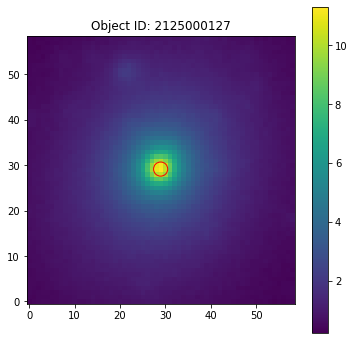

e1 true: 0.053159868238147834
e2 true: 0.05922915253278299
shear_1 true: 2.791596874079927e-05
shear_2 true: 6.348823931766609e-05
redshift true: 0.04859204218889346


In [311]:
# Plot just one
i = 6
first = id_ra_dec[object_idx[i]]
print(object_idx[i], truth_idx[i])
ra, dec = first['ra'], first['dec']
frame = 0
plt.figure(frame)
cutout = cutout_img_dc2.make_cutout_image(butler, ra, dec, filter='r', label="Object ID: %d" % truth_data['galaxy_id'][truth_idx[i]])

print('e1 true: '+str(truth_data['ellipticity_1_true'][truth_idx[i]]))
print('e2 true: '+str(truth_data['ellipticity_2_true'][truth_idx[i]]))
print('shear_1 true: '+str(truth_data['shear_1'][truth_idx[i]]))
print('shear_2 true: '+str(truth_data['shear_2'][truth_idx[i]]))
print('redshift true: '+str(truth_data['redshift'][truth_idx[i]]))

# And try to reproduce noiseless image with GalSim

In [312]:
data_dir = '/sps/lsst/users/barcelin/data/'#str(os.environ.get('IMGEN_DATA'))

In [313]:
cosmos_cat_dir = os.path.join(data_dir,'COSMOS_25.2_training_sample')
cosmos_cat = galsim.COSMOSCatalog('real_galaxy_catalog_25.2.fits', dir=cosmos_cat_dir)

In [314]:
pd_truth = pd.DataFrame.from_dict(truth_data)

In [315]:
for k,key in enumerate (quantities):
    print(key,pd_truth[key][i])

galaxy_id 2125000127
ra 63.283219368305694
dec -28.538967566696634
mag_r 17.146075010509712
mag_r_lsst 17.146075010509712
redshift 0.04859204218889346
ellipticity_true 0.07958683
convergence -9.115595751563177e-06
ellipticity_1_true 0.053159868238147834
ellipticity_2_true 0.05922915253278299
morphology/totalEllipticity1 0.079248056
morphology/totalEllipticity2 -0.0073354947
shear_1 2.791596874079927e-05
shear_2 6.348823931766609e-05
sersic_disk 1.0
sersic_bulge 4.0
ellipticity_1_disk_true 0.06143270528254158
ellipticity_2_disk_true 0.06844650282767391
ellipticity_1_bulge_true 0.01315260044202697
ellipticity_2_bulge_true 0.014654238311759714
size_disk_true 5.1029167
size_bulge_true 2.3783805
bulge_to_total_ratio_i 0.18303888
morphology/diskHalfLightRadiusArcsec 5.102916724135428
morphology/diskHalfLightRadius 4.833029236977048


In [316]:
pixel_scale = 0.02
psf = galsim.Kolmogorov(fwhm=0.32) # PSF can be fixed for this
image_size = 64

<img src="imgs/flux_def.png" alt="Drawing" style="width: 1200px;"/>

In [317]:
datapath = '/pbs/home/b/barcelin/pbs_throng_link/image_generation_GalSim/data/share_galsim/'
# read in SEDs
SED_names = ['CWW_E_ext', 'CWW_Sbc_ext', 'CWW_Scd_ext', 'CWW_Im_ext']
SEDs = {}
for SED_name in SED_names:
    SED_filename = os.path.join(datapath, 'SEDs/{0}.sed'.format(SED_name))
    # Here we create some galsim.SED objects to hold star or galaxy spectra.  The most
    # convenient way to create realistic spectra is to read them in from a two-column ASCII
    # file, where the first column is wavelength and the second column is flux. Wavelengths in
    # the example SED files are in Angstroms, flux in flambda.  We use a set of files that are
    # distributed with GalSim in the share/ directory.
    SED = galsim.SED(SED_filename, wave_type='Ang', flux_type='flambda')
    # The normalization of SEDs affects how many photons are eventually drawn into an image.
    # One way to control this normalization is to specify the flux density in photons per nm
    # at a particular wavelength.  For example, here we normalize such that the photon density
    # is 1 photon per nm at 500 nm.
    SEDs[SED_name] = SED.withFluxDensity(target_flux_density=1.0, wavelength=500)
    
lsst_filters_dir = os.path.join(datapath, 'bandpasses')
filters = {}
# read in the LSST filters
filter_names_lsst = 'ugrizy'
for filter_name in filter_names_lsst:
    filter_filename = os.path.join(lsst_filters_dir, 'LSST_{0}.dat'.format(filter_name))
    filters[filter_name] = galsim.Bandpass(filter_filename, wave_type='nm')
    filters[filter_name] = filters[filter_name].thin(rel_err=1e-4)

In [318]:
bulge_n = pd_truth['sersic_bulge'][i]
disk_n = pd_truth['sersic_disk'][i]
bulge_re = pd_truth['size_bulge_true'][i]
disk_re = pd_truth['size_disk_true'][i]
e1_galsim = pd_truth['ellipticity_1_true'][i]
e2_galsim = pd_truth['ellipticity_2_true'][i]
e1_disk = pd_truth['ellipticity_1_disk_true'][i]
e2_disk = pd_truth['ellipticity_2_disk_true'][i]
e1_bulge = pd_truth['ellipticity_1_bulge_true'][i]
e2_bulge = pd_truth['ellipticity_2_bulge_true'][i]

frac = pd_truth['bulge_to_total_ratio_i'][i]
wcs_g1 = pd_truth['shear_1'][i]
wcs_g2 = pd_truth['shear_2'][i]
#flux_gal = 10**((24.5-pd_truth['mag_r_lsst'][i])/2.5) # conversion of magnitude to flux

bulge = galsim.Sersic(bulge_n, half_light_radius=bulge_re)#, flux = flux_gal)
disk = galsim.Sersic(disk_n, half_light_radius=disk_re)#, flux = flux_gal)

#disk_SED = SEDs['CWW_Im_ext'].atRedshift(pd_truth['redshift'][i]+0.2)
#disk = disk * disk_SED
shape_d = galsim.Shear(e1=-e1_disk, e2=e2_disk)
disk = disk.shear(shape_d)

#bulge_SED = SEDs['CWW_E_ext'].atRedshift(pd_truth['redshift'][i]+0.2)
#bulge = bulge * bulge_SED
shape_b = galsim.Shear(e1=e1_bulge, e2=e2_bulge)
bulge = bulge.shear(shape_b)

#gal = frac * bulge + (1-frac) * disk
gal = frac * bulge + (1-frac) *  disk

s = galsim.Shear(g1=-wcs_g1, g2=wcs_g2)
gal = gal.shear(s)

In [319]:
final = galsim.Convolve([psf, gal])
image = galsim.ImageF(image_size, image_size)
final.drawImage(image=image)#filters['r'], 

galsim.Image(bounds=galsim.BoundsI(xmin=1, xmax=64, ymin=1, ymax=64), array=
array([[3.2924225e-05, 3.3610653e-05, 3.4301123e-05, ..., 3.1965952e-05,
        3.1284239e-05, 3.0609655e-05],
       [3.3546261e-05, 3.4260720e-05, 3.4980323e-05, ..., 3.2637970e-05,
        3.1929318e-05, 3.1228814e-05],
       [3.4170407e-05, 3.4913872e-05, 3.5663703e-05, ..., 3.3317257e-05,
        3.2580629e-05, 3.1853273e-05],
       ...,
       [3.1853258e-05, 3.2580614e-05, 3.3317243e-05, ..., 3.5663717e-05,
        3.4913883e-05, 3.4170422e-05],
       [3.1228803e-05, 3.1929303e-05, 3.2637956e-05, ..., 3.4980338e-05,
        3.4260731e-05, 3.3546276e-05],
       [3.0609641e-05, 3.1284228e-05, 3.1965938e-05, ..., 3.4301134e-05,
        3.3610664e-05, 3.2924236e-05]], dtype=float32), wcs=galsim.PixelScale(0.07945139981688676))

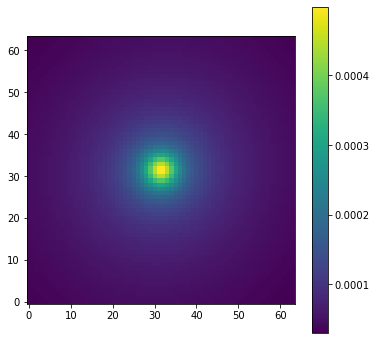

In [320]:
plt.imshow(image.array, origin = "lower")
plt.colorbar()

In [321]:
img = image.array * np.max((cutout.image.array[27:31,27:31])-np.mean(cutout.image.array[:10,:10]))/np.max(image.array)#[:10,:10]

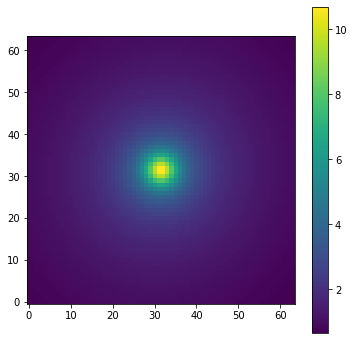

In [322]:
plt.imshow(img, origin = "lower")
plt.colorbar()

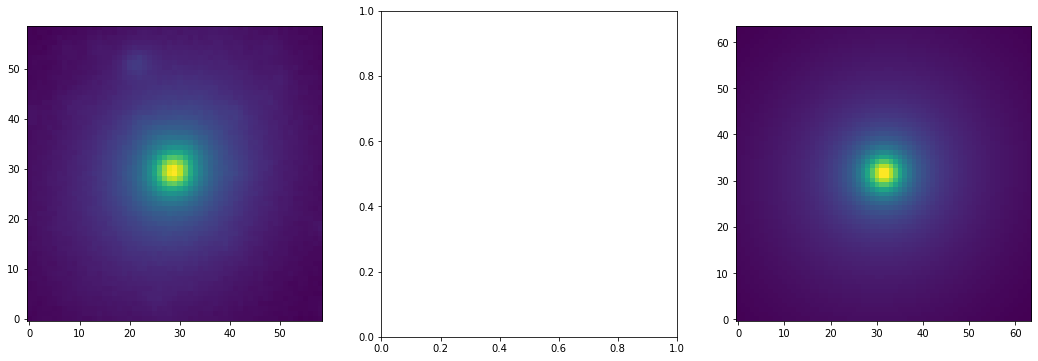

In [323]:
fig, axes = plt.subplots(1,3,figsize = (18,6))
axes[0].imshow(cutout.image.array, origin = "lower")
#axes[1].imshow(cutout.image.array-img[], origin = "lower")
axes[2].imshow(img, origin = "lower")
np.save('img.npy', img)

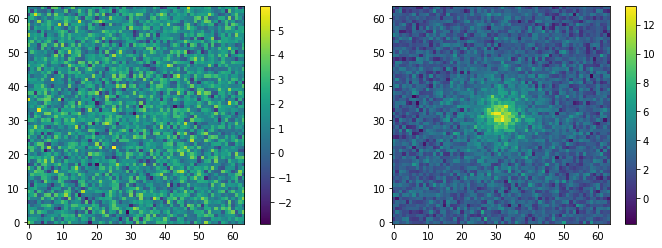

In [324]:
fig, axes = plt.subplots(1,2, figsize = (12,4))
fig1 = axes[0].imshow(np.random.normal(np.mean(cutout.image.array), np.std(cutout.image.array), img.shape), origin = "lower")
fig2 = axes[1].imshow(np.random.normal(np.mean(cutout.image.array), np.std(cutout.image.array), img.shape)+img, origin = "lower")
fig.colorbar(fig1 ,ax=axes[0])
fig.colorbar(fig2 ,ax=axes[1])

## Plot in rgb with DM stack

In [325]:
import lsst.afw.display as afwDisplay
import lsst.afw.display.rgb as rgb

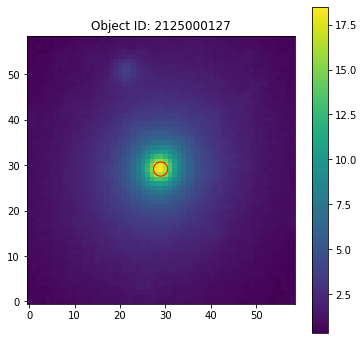

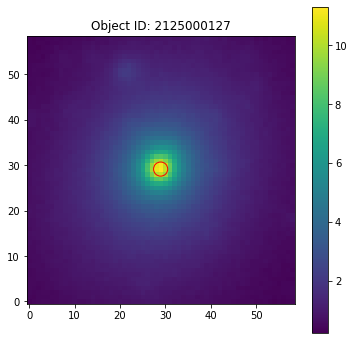

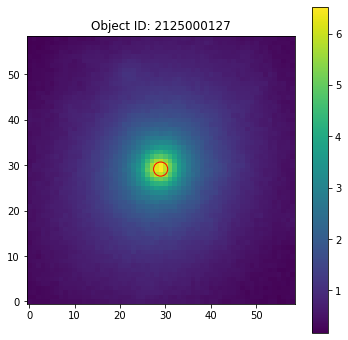

In [326]:
cutouts = [cutout_img_dc2.make_cutout_image(butler, ra, dec, filter=band, label="Object ID: %d" % truth_data['galaxy_id'][truth_idx[i]]) for band in "irg"]
#cutout = cutout_img_dc2.make_cutout_image(butler, ra, dec, filter='r', label="Object ID: %d" % truth_data['galaxy_id'][truth_idx[i]])


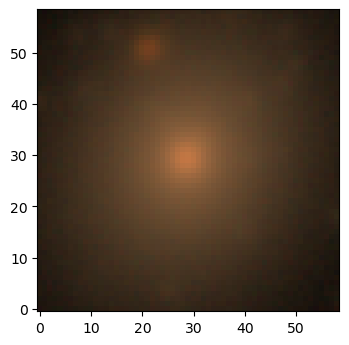

In [327]:
image_rgb = rgb.makeRGB(*cutouts)
#del cutouts  # let gc save some memory for us

fig, ax = plt.subplots(1, figsize=(4, 4), dpi=100)
ax.imshow(image_rgb, origin='lower')
#ax.set_xlabel("RA")
#ax.set_ylabel("Dec")

In [328]:
ra = pd_truth['ra']
dec = pd_truth['dec']
cutout_size = 64
cutout_extent = lsst.geom.ExtentI(cutout_size,cutout_size)

In [329]:
skymap = butler.get('deepCoadd_skyMap')

def get_tract_patch(ra, dec, units=lsst.geom.degrees):
    radec =  lsst.geom.SpherePoint(ra, dec, units)
    tractInfo = skymap.findTract(radec)
    patchInfo = tractInfo.findPatch(radec)
    return tractInfo.getId(), "{},{}".format(*patchInfo.getIndex())


tract = get_tract_patch(ra[i], dec[i])[0]
patch = get_tract_patch(ra[i], dec[i])[1]

print(tract, patch)

4855 6,5


In [330]:
center.x - cutout_size*0.5+1, center.y - cutout_size*0.5+1

(24088.317175510776, 23874.956604599047)

In [331]:
radec = lsst.geom.SpherePoint(ra[i], dec[i], lsst.geom.degrees)

center = skymap.findTract(radec).getWcs().skyToPixel(radec)
bbox = lsst.geom.BoxI(lsst.geom.Point2I((center.x - cutout_size*0.5, center.y - cutout_size*0.5)), cutout_extent)

dataId = {"tract": tract, "patch": patch, "filter": "r"}

In [332]:
cutout = butler.get("deepCoadd_sub", dataId=dataId, bbox=bbox)

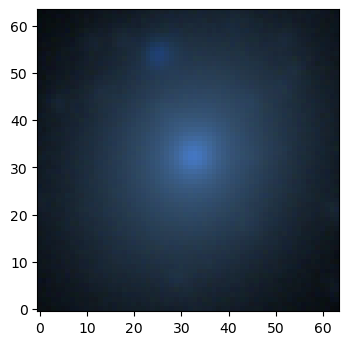

In [333]:
# Note how we directly supply keyword arguments instead of a single dataId dictionary here
# Also note the band ordering. We will use "irg" for "RGB", respectively. 
cutouts = [butler.get("deepCoadd_sub", bbox=bbox, tract=tract, patch=patch, filter=band) for band in "gri"]

wcs_fits_meta = cutouts[0].getWcs().getFitsMetadata()
image_rgb = rgb.makeRGB(*cutouts)
#del cutouts  # let gc save some memory for us

fig, ax = plt.subplots(1, figsize=(4, 4), dpi=100)
ax.imshow(image_rgb, origin='lower')
#ax.set_xlabel("RA")
#ax.set_ylabel("Dec")

## Plot in RGB with scarlet

In [334]:
import scarlet
import scarlet.display
from lsst.afw.image import MultibandExposure

In [335]:
filters='grizy'

In [336]:
cutouts = [butler.get("deepCoadd_sub", bbox=bbox, tract=tract, patch=patch, filter=band) for band in "grizy"]
coadds = MultibandExposure.fromExposures(filters, cutouts)

norm = scarlet.display.AsinhMapping(minimum=0, stretch=1, Q=10)
rgb_patch = scarlet.display.img_to_rgb(coadds.image.array, norm=norm)

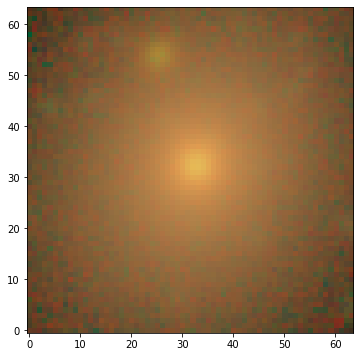

In [337]:
plt.figure(figsize = (6,6))
plt.imshow(rgb_patch, origin = "lower")
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()

In [338]:
np.max(rgb_patch), np.min(rgb_patch)

(230, 0)

In [339]:
np.min(pd_truth['mag_r_lsst'])

13.025821602872803

In [340]:
repo = '/sps/lssttest/dataproducts/desc/DC2/Run2.2i/v19.0.0-v1/rerun/run2.2i-coadd-wfd-dr6-v1-u'
butler_u = dafPersist.Butler(repo)
cutouts_u = [butler_u.get("deepCoadd_sub", bbox=bbox, tract=tract, patch=patch, filter=band) for band in "u"]

## load image generated with Galsim

In [341]:
data_dir = "/sps/lsst/users/barcelin/data/blended_galaxies/27.5/centered/test/"

data_sim = np.load(data_dir+'galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

In [342]:
data_sim.shape

(10000, 2, 10, 64, 64)

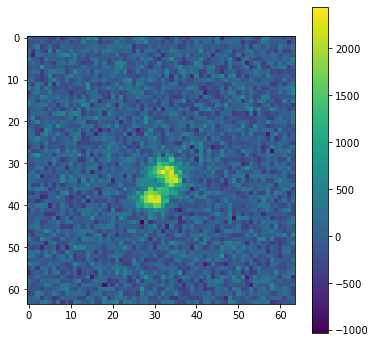

In [343]:
plt.imshow(data_sim[2,1,6])
plt.colorbar()

In [344]:
np.mean(data_sim[2,1,6][:10,:10]), np.std(data_sim[2,1,6][:10,:10])

(-19.39109375, 258.82806957515254)

In [345]:
frac = np.std(data_sim[2,1,6][:10,:10])/np.std(cutout.image.array[:10,:10])
frac

3097.397915233845

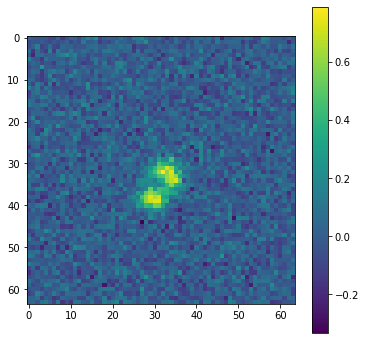

In [346]:
plt.imshow(data_sim[2,1,6]/frac)
plt.colorbar()

In [347]:
np.mean(data_sim[2,1,6][:10,:10]/frac), np.std(data_sim[2,1,6][:10,:10]/frac)

(-0.006260446439454654, 0.08356306701898575)

In [348]:
np.min(data_sim[2,1,6]/frac)

-0.33281842435545517

## Test deblending with trained VAE

In [349]:
#sys.path.insert(0,'../../../Deblender_VAE/scripts/tools_for_VAE/')
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE
import tools_for_VAE.utils as utils
import tools_for_VAE.vae_functions as vae_functions

In [350]:
reload(utils)

<module 'tools_for_VAE.utils' from '../../scripts/tools_for_VAE/tools_for_VAE/utils.py'>

In [351]:
latent_dim = 32
bands = [4,5,6,7,8,9]

path_output = '/sps/lsst/users/barcelin/weights/LSST/deblender/noisy/v_2/v_centered/bis/bis/mse/'
path_output_miscenter_01 = '/sps/lsst/users/barcelin/weights/LSST/deblender/noisy/v_2/v_miscentered_01/bis/bis/mse/'
path_output_miscenter_peak = '/sps/lsst/users/barcelin/weights/LSST/deblender/noisy/v_2/v_miscentered_peak/bis/bis/mse/'

In [352]:
import tensorflow.keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import metrics
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Add, Multiply, Reshape, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, Input, Dense, Dropout, MaxPool2D, Flatten,  Reshape, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda, BatchNormalization, concatenate, LeakyReLU


#### Create encooder
def build_encoder(latent_dim, hidden_dim, filters, kernels,nb_of_bands, conv_activation=None, dense_activation=None):#'sofplus'
    """
    Return encoder as model
    latent_dim : dimension of the latent variable
    hidden_dim : dimension of the dense hidden layer
    filters: list of the sizes of the filters used for this model
    list of the size of the kernels used for each filter of this model
    conv_activation: type of activation layer used after the convolutional layers
    dense_activation: type of activation layer used after the dense layers
    nb_of bands : nb of band-pass filters needed in the model
    """
    input_layer = Input(shape=(64,64,nb_of_bands))

    h = Reshape((64,64,nb_of_bands))(input_layer)
    h = BatchNormalization()(h)
    for i in range(len(filters)):
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        h = PReLU()(h)
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
    h = Flatten()(h)
    h = Dense(hidden_dim, activation=dense_activation)(h)
    h = PReLU()(h)
    mu = Dense(latent_dim)(h)
    sigma = Dense(latent_dim, activation='softplus')(h)
    return Model(input_layer, [mu, sigma])


#### Create encooder
def build_decoder(input_shape, latent_dim, hidden_dim, filters, kernels, conv_activation=None, dense_activation=None):
    """
    Return decoder as model
    input_shape: shape of the input data
    latent_dim : dimension of the latent variable
    hidden_dim : dimension of the dense hidden layer
    filters: list of the sizes of the filters used for this model
    list of the size of the kernels used for each filter of this model
    conv_activation: type of activation layer used after the convolutional layers
    dense_activation: type of activation layer used after the dense layers
    """
    input_layer = Input(shape=(latent_dim,))
    h = Dense(hidden_dim, activation=dense_activation)(input_layer)
    h = PReLU()(h)
    w = int(np.ceil(input_shape[0]/2**(len(filters))))
    h = Dense(w*w*filters[-1], activation=dense_activation)(h)
    h = PReLU()(h)
    h = Reshape((w,w,filters[-1]))(h)
    for i in range(len(filters)-1,-1,-1):
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        h = PReLU()(h)
    h = Conv2D(input_shape[-1], (3,3), activation='sigmoid', padding='same')(h)
    cropping = int(h.get_shape()[1]-input_shape[0])
    if cropping>0:
        print('in cropping')
        if cropping % 2 == 0:
            h = Cropping2D(cropping/2)(h)
        else:
            h = Cropping2D(((cropping//2,cropping//2+1),(cropping//2,cropping//2+1)))(h)

    return Model(input_layer, h)



# Function to define model

def vae_model(latent_dim, nb_of_bands):
    """
    Function to create VAE model
    nb_of bands : nb of band-pass filters needed in the model
    """

    #### Parameters to fix
    # batch_size : size of the batch given to the network
    # input_shape: shape of the input data
    # latent_dim : dimension of the latent variable
    # hidden_dim : dimension of the dense hidden layer
    # filters: list of the sizes of the filters used for this model
    # kernels: list of the size of the kernels used for each filter of this model

    batch_size = 100 
    
    input_shape = (64, 64, nb_of_bands)
    hidden_dim = 256
    filters = [32, 64, 128, 256]
    kernels = [3,3,3,3]

    # Build the encoder
    encoder = build_encoder(latent_dim, hidden_dim, filters, kernels, nb_of_bands)
    # Build the decoder
    decoder = build_decoder(input_shape, latent_dim, hidden_dim, filters, kernels, conv_activation=None, dense_activation=None)

    
    return encoder, decoder

In [353]:
encoder, decoder = vae_model(latent_dim, len(bands))
net_deblender, net_deblender_utils,  Dkl = vae_functions.build_vanilla_vae(encoder, decoder, full_cov=False, coeff_KL = 0)

latest = tf.train.latest_checkpoint(path_output_miscenter_01)
net_deblender.load_weights(latest)

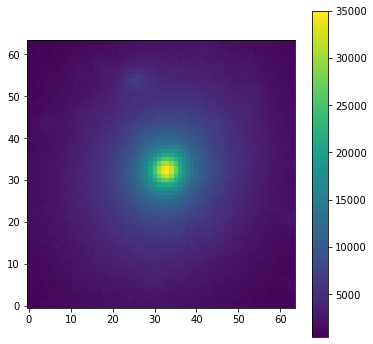

In [354]:
cutout_denorm = cutout.image.array*frac
plt.imshow(cutout_denorm, origin = 'lower')
plt.colorbar()

In [355]:
img = np.zeros((1,6,64,64))

for i in range (6):
    if i ==0:
        img[0,i]=cutouts_u[0].image.array
        img[0,i] = img[0,i]*np.std(data_sim[2,1,4+i][:10,:10])/np.std(cutouts_u[0].image.array[:10,:10])
        
    else:
        img[0,i]= cutouts[i-1].image.array
        img[0,i] = img[0,i]*np.std(data_sim[2,1,4+i][:10,:10])/np.std(cutouts[i-1].image.array[:10,:10])

In [356]:
img.shape

(1, 6, 64, 64)

In [357]:
cutout_norm = utils.norm(img, bands,data_dir, channel_last=False, inplace=False)

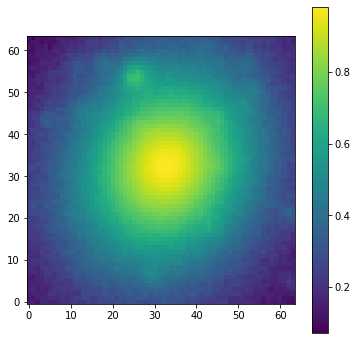

In [358]:
plt.imshow(cutout_norm[0,2], origin = 'lower')
plt.colorbar()

In [359]:
output = []
for i in range (100):
    output.append(net_deblender.predict(np.transpose(cutout_norm, axes = (0,2,3,1))))

In [360]:
output = np.array(output)
print(output.shape)
output = np.squeeze(output)
print(output.shape)
output_mean = np.mean(output, axis = 0)
print(output_mean.shape)
output_mean = np.expand_dims(output_mean, axis = 0)
print(output_mean.shape)

(100, 1, 64, 64, 6)
(100, 64, 64, 6)
(64, 64, 6)
(1, 64, 64, 6)


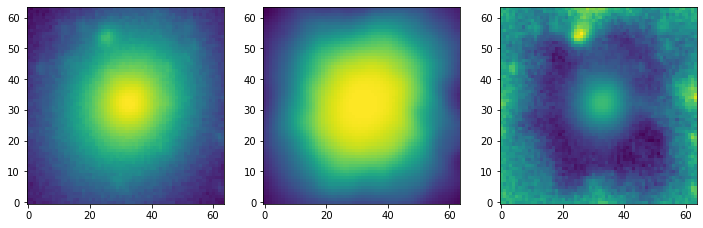

In [361]:
fig, axes = plt.subplots(1,3, figsize = (12,4))
axes[0].imshow(cutout_norm[0,2], origin = 'lower')
axes[1].imshow(output_mean[0,:,:,2], origin = 'lower')
axes[2].imshow(cutout_norm[0,2]-output_mean[0,:,:,2], origin = 'lower')

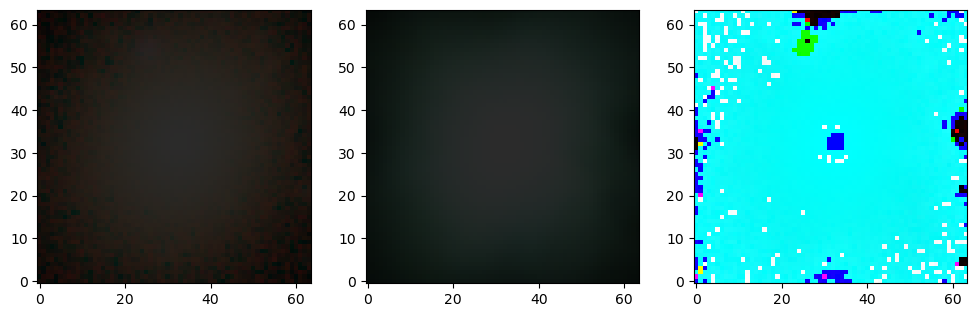

In [362]:
cutouts_output = [output_mean[0,:,:,i] for i in range (6)]
cutouts_input = [cutout_norm[0,i] for i in range (6)]

image_rgb_in = rgb.makeRGB(*cutouts_input[:3])
image_rgb_out = rgb.makeRGB(*cutouts_output[:3])
#del cutouts  # let gc save some memory for us

fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
ax[0].imshow(image_rgb_in, origin='lower')
ax[1].imshow(image_rgb_out, origin='lower')
ax[2].imshow(image_rgb_in-image_rgb_out, origin='lower')